# 📊 Exploratory Data Analysis (EDA)

**Dataset:** Paderborn University PMSM (Permanent Magnet Synchronous Motor) Temperature Dataset  
**Rows:** 1,330,816 sensor readings at 2Hz sampling rate  
**Source:** Kaggle (Open Data License)  

This notebook explores the statistical distribution, correlation structure, and physical relationships between the 12 sensor channels of an automotive-grade electric motor.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv('../data/comprehensive_fault_training_data.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Memory Usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Dataset Shape: (1330816, 13)
Memory Usage: 138.4 MB


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


## 1. Statistical Summary
Understanding the scale, mean, and variance of each sensor channel. This tells us whether standardization (StandardScaler) is necessary before feeding into XGBoost.

In [10]:
desc = df.describe().T
desc['range'] = desc['max'] - desc['min']
desc['cv'] = desc['std'] / desc['mean']  # coefficient of variation
desc[['mean', 'std', 'min', 'max', 'range', 'cv']].round(3)

,mean,std,min,max,range,cv
u_q,54.279,44.173,-25.291,133.037,158.328,0.814
coolant,36.230,21.786,10.624,101.599,90.975,0.601
stator_winding,66.343,28.672,18.586,141.363,122.777,0.432
u_d,-25.134,63.092,-131.530,131.470,263.000,-2.510
stator_tooth,56.879,22.952,18.134,111.946,93.812,0.404
motor_speed,2202.081,1859.663,-275.549,6000.015,6275.564,0.845
i_d,-68.717,64.933,-278.004,0.052,278.056,-0.945
i_q,37.413,92.182,-293.427,301.708,595.135,2.464
pm,58.507,19.001,20.857,113.607,92.750,0.325
stator_yoke,48.188,19.991,18.077,101.148,83.071,0.415


## 2. Missing Values & Data Quality
Real-world sensor data often contains NaN values from dropped CAN bus packets. Let's verify data integrity.

In [11]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values detected. Dataset is pristine.')
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
No missing values detected. Dataset is pristine.

Duplicate rows: 0


## 3. Feature Distributions
Histograms reveal the shape of each sensor's output. Skewed distributions may need log transforms. Bimodal distributions may indicate distinct operating modes (idle vs. highway).

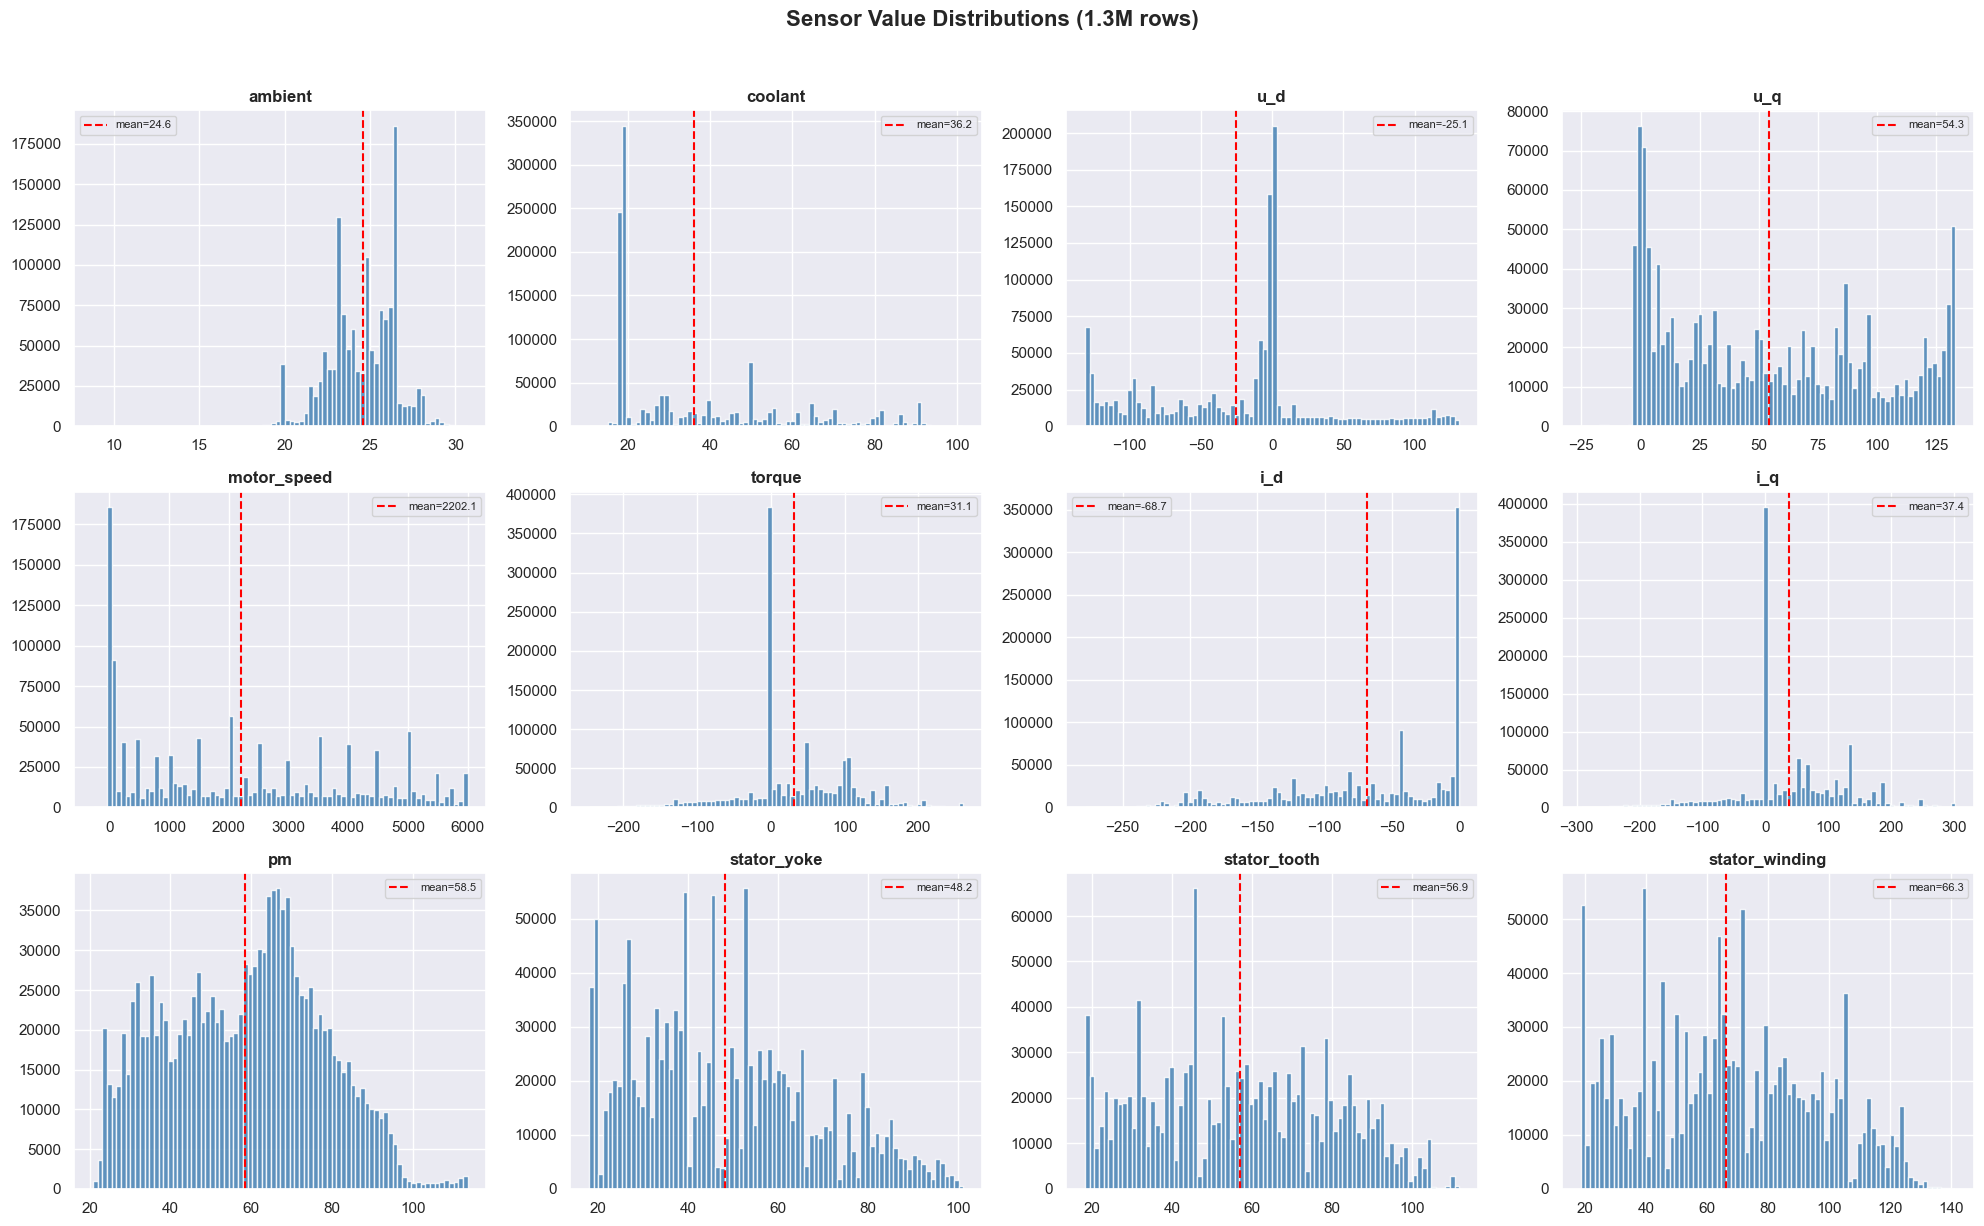

In [12]:
sensor_cols = ['ambient', 'coolant', 'u_d', 'u_q', 'motor_speed', 'torque',
               'i_d', 'i_q', 'pm', 'stator_yoke', 'stator_tooth', 'stator_winding']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flat, sensor_cols):
    ax.hist(df[col], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'mean={df[col].mean():.1f}')
    ax.legend(fontsize=8)
plt.suptitle('Sensor Value Distributions (1.3M rows)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Correlation Matrix
The Pearson correlation heatmap reveals which sensors move together. High correlation between `stator_winding` and `stator_tooth` is expected (they are physically adjacent copper coils). Negative correlation between `coolant` and thermal sensors would indicate the cooling system is working.

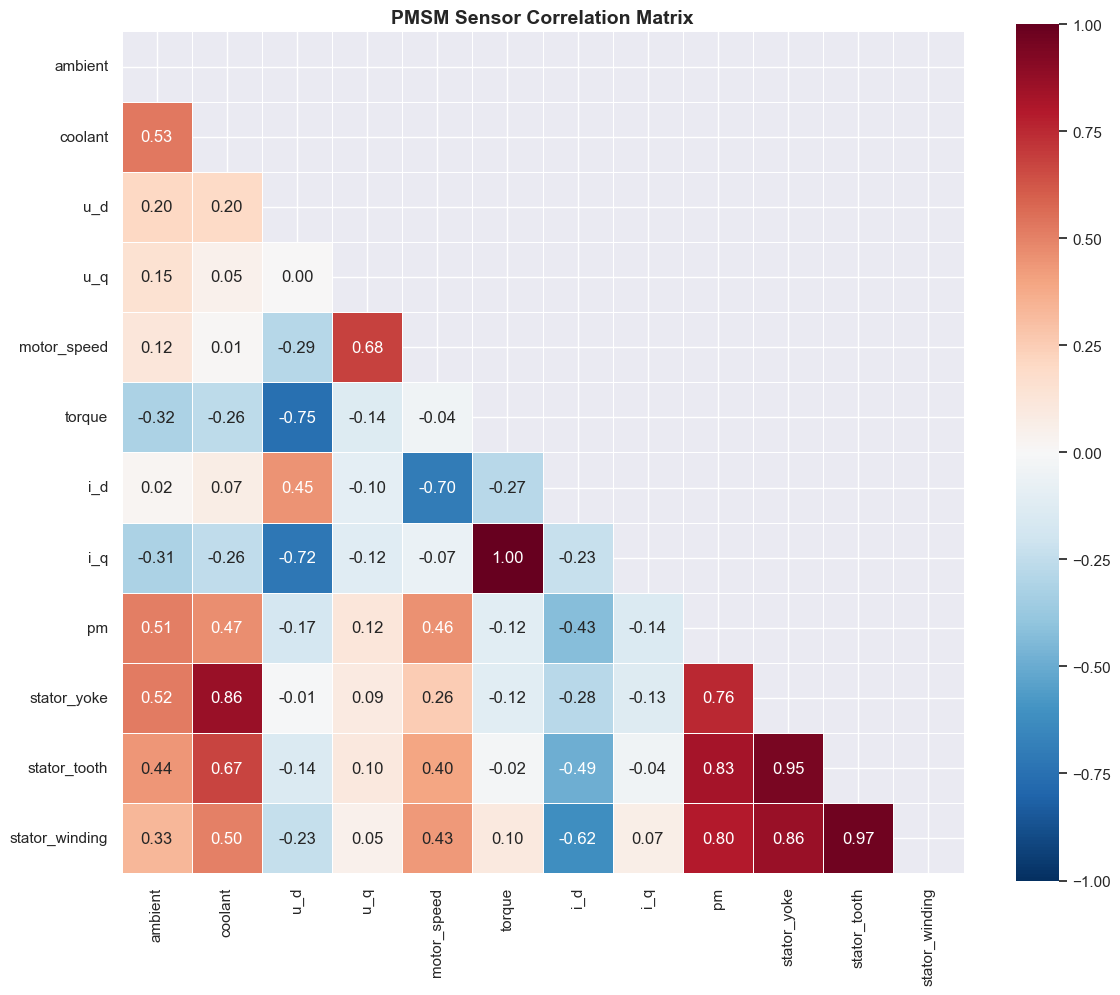

In [13]:
corr = df[sensor_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('PMSM Sensor Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Thermal Cascade Analysis
The critical failure mode in a PMSM is stator winding meltdown. Let's visualize how temperature propagates through the motor: ambient → coolant → stator_yoke → stator_tooth → stator_winding.

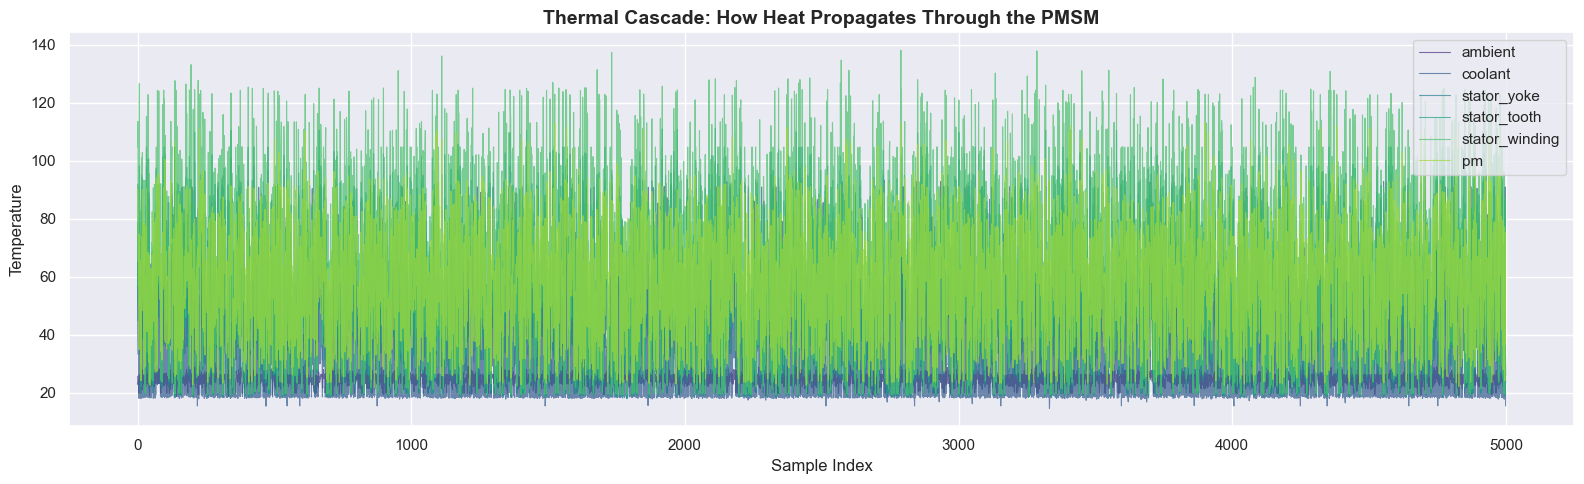

In [14]:
thermal_cols = ['ambient', 'coolant', 'stator_yoke', 'stator_tooth', 'stator_winding', 'pm']
sample = df[thermal_cols].sample(n=5000, random_state=42).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 5))
for col in thermal_cols:
    ax.plot(sample[col], label=col, alpha=0.7, linewidth=0.8)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Temperature')
ax.set_title('Thermal Cascade: How Heat Propagates Through the PMSM', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Driving Profile Analysis
The dataset contains multiple driving profiles (highway, city, mixed). Each profile stresses the motor differently.

Unique driving profiles: 69

Rows per profile:
profile_id
20    43971
6     40388
65    40094
18    37732
66    36476
13    35906
27    35361
4     33424
58    33382
56    33123
Name: count, dtype: int64


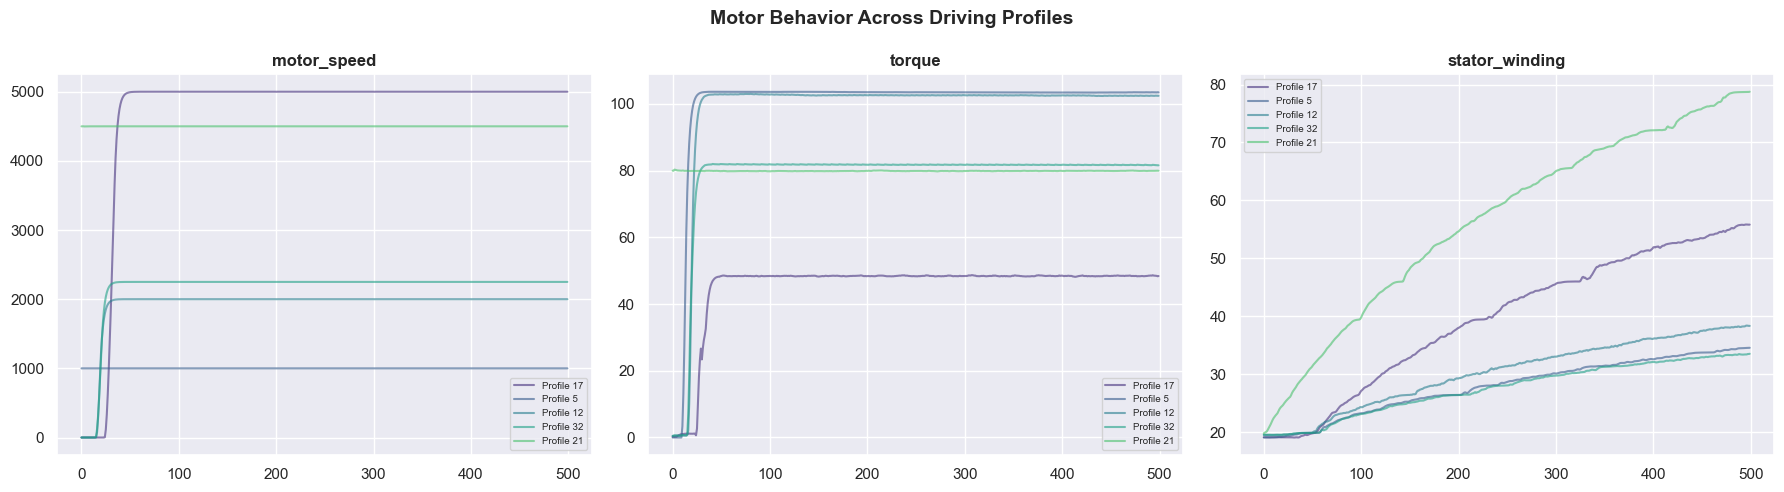

In [15]:
print(f'Unique driving profiles: {df["profile_id"].nunique()}')
print(f'\nRows per profile:')
print(df['profile_id'].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['motor_speed', 'torque', 'stator_winding']):
    for pid in df['profile_id'].unique()[:5]:
        subset = df[df['profile_id'] == pid][col].values[:500]
        ax.plot(subset, alpha=0.6, label=f'Profile {pid}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
plt.suptitle('Motor Behavior Across Driving Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Takeaways

1. **No missing data** — The Paderborn dataset is laboratory-grade with zero dropped packets.
2. **Strong thermal correlation** — `stator_winding`, `stator_tooth`, and `stator_yoke` are highly correlated (all part of the stator assembly).
3. **Wide dynamic range** — `motor_speed` and `torque` have vastly different scales, confirming the need for `StandardScaler` before XGBoost.
4. **Multiple driving profiles** — The dataset represents diverse real-world operating conditions, reducing overfitting risk.